In [19]:
import random
import time
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display
from collections import deque

In [10]:
width = 21
height = 21

directions = [
    (0, -2),   # 上
    (2, 0),    # 右
    (0, 2),    # 下
    (-2, 0),   # 左
]


def can_dig(x, y, maze):
    h, w = maze.shape

    return (
        1 <= x < w - 1
        and 1 <= y < h - 1
        and maze[y, x] == 1
    )


def generate_maze(width, height, delay=0.1):
    if width < 5 or height < 5:
        raise ValueError("幅と高さは5以上にしてください")

    if width % 2 == 0 or height % 2 == 0:
        raise ValueError("幅と高さは奇数にしてください")

    # 1: 壁、0: 通路
    maze = np.ones((height, width), dtype=np.int8)

    start_x, start_y = 1, 1
    goal_x, goal_y = width - 2, height - 2

    # スタートだけを最初に掘る
    maze[start_y, start_x] = 0

    stack = [(start_x, start_y)]

    fig, ax = plt.subplots(figsize=(7, 7))

    image = ax.imshow(
        maze,
        cmap="binary",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.scatter(
        start_x,
        start_y,
        c="green",
        s=100,
        label="Start",
        zorder=3,
    )

    ax.scatter(
        goal_x,
        goal_y,
        c="red",
        s=100,
        label="Goal",
        zorder=3,
    )

    # 現在掘っている位置
    current_plot = ax.scatter(
        start_x,
        start_y,
        c="blue",
        s=50,
        label="Current",
        zorder=4,
    )

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

    while stack:
        now_x, now_y = stack[-1]

        shuffled_directions = directions.copy()
        random.shuffle(shuffled_directions)

        moved = False

        for dx, dy in shuffled_directions:
            next_x = now_x + dx
            next_y = now_y + dy

            if can_dig(next_x, next_y, maze):
                wall_x = now_x + dx // 2
                wall_y = now_y + dy // 2

                maze[wall_y, wall_x] = 0
                maze[next_y, next_x] = 0

                stack.append((next_x, next_y))
                moved = True

                current_plot.set_offsets([[next_x, next_y]])

                break

        if not moved:
            stack.pop()

            if stack:
                back_x, back_y = stack[-1]
                current_plot.set_offsets([[back_x, back_y]])

        # 同じ出力欄を更新
        image.set_data(maze)
        fig.canvas.draw()

        clear_output(wait=True)
        display(fig)

        time.sleep(delay)

    clear_output(wait=True)

    # 最終状態を表示
    current_plot.remove()
    image.set_data(maze)
    display(fig)

    plt.close(fig)

    return maze, (start_x, start_y), (goal_x, goal_y)

In [ ]:
def check_maze(maze, start, goal):
    h, w = maze.shape

    queue = deque([start])
    visited = {start}

    directions_1step = [
        (0, -1),
        (1, 0),
        (0, 1),
        (-1, 0),
    ]

    while queue:
        x, y = queue.popleft()

        for dx, dy in directions_1step:
            next_x = x + dx
            next_y = y + dy

            if not (0 <= next_x < w and 0 <= next_y < h):
                continue

            if maze[next_y, next_x] == 1:
                continue

            if (next_x, next_y) in visited:
                continue

            visited.add((next_x, next_y))
            queue.append((next_x, next_y))

    passage_count = int(np.sum(maze == 0))
    reachable_count = len(visited)

    print(f"通路の総数: {passage_count}")
    print(f"スタートから到達できる通路数: {reachable_count}")
    print(f"ゴール到達可能: {goal in visited}")
    print(f"全通路が連結: {passage_count == reachable_count}")


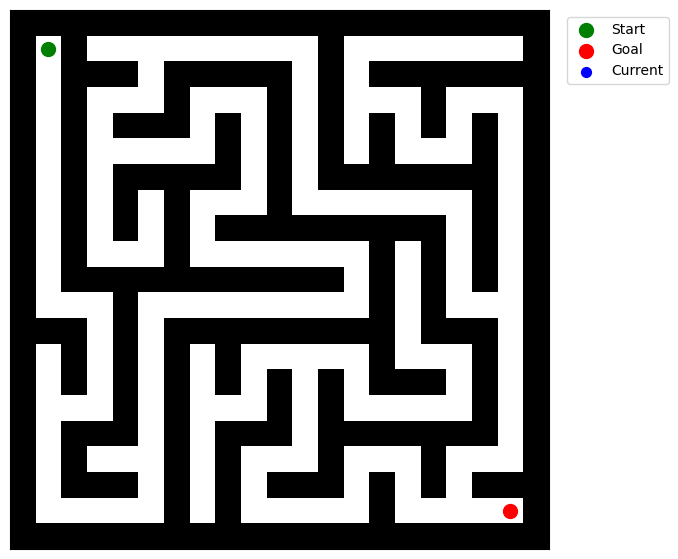

通路の総数: 199
スタートから到達できる通路数: 199
ゴール到達可能: True
全通路が連結: True


In [12]:
maze, start, goal = generate_maze(21, 21, delay=0.001)
check_maze(maze, start, goal)

In [13]:
def check_perfect_maze(maze, start, goal):
    h, w = maze.shape

    passage_count = int(np.sum(maze == 0))
    edge_count = 0

    for y in range(h):
        for x in range(w):
            if maze[y, x] != 0:
                continue

            # 右隣との接続
            if x + 1 < w and maze[y, x + 1] == 0:
                edge_count += 1

            # 下隣との接続
            if y + 1 < h and maze[y + 1, x] == 0:
                edge_count += 1

    queue = deque([start])
    visited = {start}

    for_search = [
        (0, -1),
        (1, 0),
        (0, 1),
        (-1, 0),
    ]

    while queue:
        x, y = queue.popleft()

        for dx, dy in for_search:
            next_x = x + dx
            next_y = y + dy

            if (
                0 <= next_x < w
                and 0 <= next_y < h
                and maze[next_y, next_x] == 0
                and (next_x, next_y) not in visited
            ):
                visited.add((next_x, next_y))
                queue.append((next_x, next_y))

    all_connected = len(visited) == passage_count
    no_loop = edge_count == passage_count - 1

    print(f"通路マス数: {passage_count}")
    print(f"通路間の接続数: {edge_count}")
    print(f"全通路が連結: {all_connected}")
    print(f"ループなし: {no_loop}")
    print(f"完全迷路: {all_connected and no_loop}")
    print(f"ゴール到達可能: {goal in visited}")

check_perfect_maze(maze, start, goal)

通路マス数: 199
通路間の接続数: 198
全通路が連結: True
ループなし: True
完全迷路: True
ゴール到達可能: True


In [18]:
solve_directions = [
    (0, -1),  # 上
    (1, 0),   # 右
    (0, 1),   # 下
    (-1, 0),  # 左
]


def search_movable_directions(maze, now_x, now_y, visited):
    h, w = maze.shape

    if not (0 <= now_x < w and 0 <= now_y < h):
        return []

    movable_directions = []

    for dx, dy in solve_directions:
        next_x = now_x + dx
        next_y = now_y + dy
        next_position = (next_x, next_y)

        # 迷路の範囲外なら進めない
        if not (0 <= next_x < w and 0 <= next_y < h):
            continue

        # 壁なら進めない
        if maze[next_y, next_x] == 1:
            continue

        # 一度探索した場所には進まない
        if next_position in visited:
            continue

        movable_directions.append((dx, dy))

    return movable_directions


def solve_maze_dfs(maze, start, goal, delay=0.05, animate=True):
    h, w = maze.shape

    start_x, start_y = start
    goal_x, goal_y = goal

    if not (0 <= start_x < w and 0 <= start_y < h):
        raise ValueError("スタートが迷路の範囲外です")

    if not (0 <= goal_x < w and 0 <= goal_y < h):
        raise ValueError("ゴールが迷路の範囲外です")

    if maze[start_y, start_x] == 1:
        raise ValueError("スタートが壁になっています")

    if maze[goal_y, goal_x] == 1:
        raise ValueError("ゴールが壁になっています")

    # 現在の探索経路
    stack = [start]

    # 一度でも調べたマス
    visited = {start}

    # 行き止まりとして戻ったマス
    backtracked = set()

    if animate:
        # RGB画像を作る
        # 壁: 黒、通路: 白
        display_maze = np.zeros((h, w, 3), dtype=float)
        display_maze[maze == 0] = [1.0, 1.0, 1.0]
        display_maze[maze == 1] = [0.0, 0.0, 0.0]

        fig, ax = plt.subplots(figsize=(8, 8))
        image = ax.imshow(display_maze, interpolation="nearest")

        ax.scatter(
            start_x,
            start_y,
            c="green",
            s=100,
            label="Start",
            zorder=4,
        )

        ax.scatter(
            goal_x,
            goal_y,
            c="red",
            s=100,
            label="Goal",
            zorder=4,
        )

        current_plot = ax.scatter(
            start_x,
            start_y,
            c="blue",
            s=60,
            label="Current",
            zorder=5,
        )

        ax.set_xticks([])
        ax.set_yticks([])
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

        def update_animation():
            frame = np.zeros((h, w, 3), dtype=float)

            # 壁と通路
            frame[maze == 0] = [1.0, 1.0, 1.0]
            frame[maze == 1] = [0.0, 0.0, 0.0]

            # 一度探索した場所を水色にする
            for x, y in visited:
                frame[y, x] = [0.65, 0.85, 1.0]

            # 行き止まりから戻った場所を灰色にする
            for x, y in backtracked:
                frame[y, x] = [0.65, 0.65, 0.65]

            # 現在有効な経路を黄色にする
            for x, y in stack:
                frame[y, x] = [1.0, 0.8, 0.2]

            image.set_data(frame)

            if stack:
                current_x, current_y = stack[-1]
                current_plot.set_offsets([[current_x, current_y]])
            else:
                current_plot.set_offsets(np.empty((0, 2)))

            clear_output(wait=True)
            display(fig)
            time.sleep(delay)

        update_animation()

    while stack:
        now_x, now_y = stack[-1]

        # ゴールに到達
        if (now_x, now_y) == goal:
            solution_path = stack.copy()

            if animate:
                update_animation()
                current_plot.remove()

                clear_output(wait=True)
                display(fig)
                plt.close(fig)

            return solution_path, visited

        movable_directions = search_movable_directions(
            maze,
            now_x,
            now_y,
            visited,
        )

        if movable_directions:
            # ランダムに進行方向を選ぶ
            random.shuffle(movable_directions)
            dx, dy = movable_directions[0]

            next_position = (now_x + dx, now_y + dy)

            stack.append(next_position)
            visited.add(next_position)

        else:
            # 未探索の方向がないので一つ前に戻る
            removed_position = stack.pop()
            backtracked.add(removed_position)

        if animate:
            update_animation()

    if animate:
        clear_output(wait=True)
        display(fig)
        plt.close(fig)

    # ゴールに到達できなかった
    return None, visited

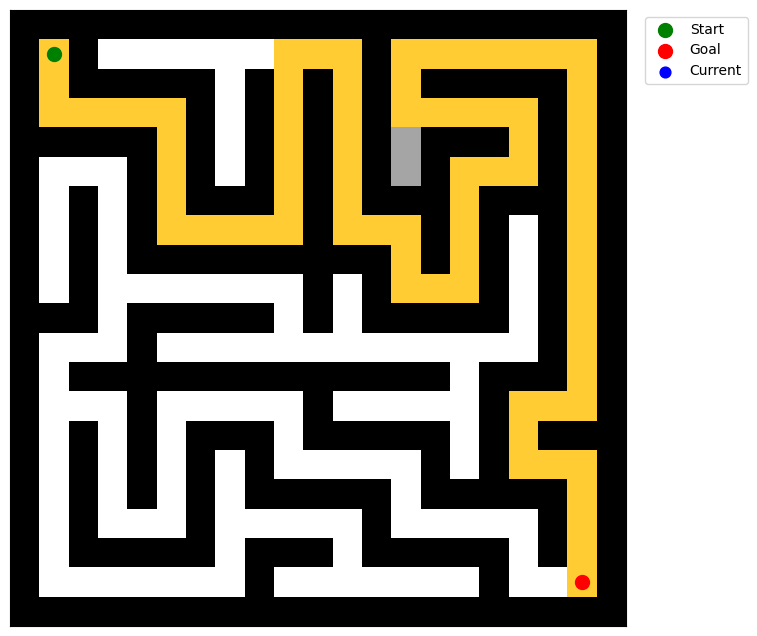

ゴールに到達しました
探索したマス数: 79
正解経路の長さ: 76
正解経路: [(1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (4, 3), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (6, 7), (7, 7), (8, 7), (9, 7), (9, 6), (9, 5), (9, 4), (9, 3), (9, 2), (9, 1), (10, 1), (11, 1), (11, 2), (11, 3), (11, 4), (11, 5), (11, 6), (11, 7), (12, 7), (13, 7), (13, 8), (13, 9), (14, 9), (15, 9), (15, 8), (15, 7), (15, 6), (15, 5), (16, 5), (17, 5), (17, 4), (17, 3), (16, 3), (15, 3), (14, 3), (13, 3), (13, 2), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (19, 2), (19, 3), (19, 4), (19, 5), (19, 6), (19, 7), (19, 8), (19, 9), (19, 10), (19, 11), (19, 12), (19, 13), (18, 13), (17, 13), (17, 14), (17, 15), (18, 15), (19, 15), (19, 16), (19, 17), (19, 18), (19, 19)]


In [25]:
maze, start, goal = generate_maze(21, 21, delay=0.01)

path, visited = solve_maze_dfs(
    maze,
    start,
    goal,
    delay=0.05,
    animate=True,
)

if path is None:
    print("ゴールまでの経路は見つかりませんでした")
else:
    print("ゴールに到達しました")
    print(f"探索したマス数: {len(visited)}")
    print(f"正解経路の長さ: {len(path) - 1}")
    print(f"正解経路: {path}")

In [ ]:
def solve_maze_bfs(maze, start, goal, delay=0.1, animate=True):
    h, w = maze.shape

    start_x, start_y = start
    goal_x, goal_y = goal

    # -------------------------
    # 入力チェック
    # -------------------------
    if not (0 <= start_x < w and 0 <= start_y < h):
        raise ValueError("スタートが迷路の範囲外です")

    if not (0 <= goal_x < w and 0 <= goal_y < h):
        raise ValueError("ゴールが迷路の範囲外です")

    if maze[start_y, start_x] == 1:
        raise ValueError("スタートが壁になっています")

    if maze[goal_y, goal_x] == 1:
        raise ValueError("ゴールが壁になっています")

    # -------------------------
    # BFSで使用するデータ
    # -------------------------
    queue = deque([start])

    # 発見済みのマス
    visited = {start}

    # 実際にキューから取り出して調べたマス
    explored = set()

    # 各マスの直前のマス
    parent = {start: None}

    # -------------------------
    # アニメーションの初期化
    # -------------------------
    if animate:
        fig, ax = plt.subplots(figsize=(8, 8))

        frame = create_bfs_frame(
            maze=maze,
            explored=explored,
            frontier=set(queue),
            current_layer=set(),
            path=None,
        )

        image = ax.imshow(
            frame,
            interpolation="nearest",
        )

        ax.scatter(
            start_x,
            start_y,
            c="green",
            s=100,
            label="Start",
            zorder=5,
        )

        ax.scatter(
            goal_x,
            goal_y,
            c="red",
            s=100,
            label="Goal",
            zorder=5,
        )

        ax.set_xticks([])
        ax.set_yticks([])
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

        update_bfs_animation(
            fig=fig,
            image=image,
            maze=maze,
            explored=explored,
            frontier=set(queue),
            current_layer=set(),
            delay=delay,
        )

    goal_found = False

    # -------------------------
    # BFS本体
    # -------------------------
    while queue:
        # 現時点のqueueには、同じ距離のマスが並んでいる
        layer_size = len(queue)

        # 今回のフレームで処理するマス
        current_layer = set()

        for _ in range(layer_size):
            now_x, now_y = queue.popleft()
            current = (now_x, now_y)

            explored.add(current)
            current_layer.add(current)

            # ゴールに到達
            if current == goal:
                goal_found = True
                break

            movable_directions = search_movable_directions(
                maze,
                now_x,
                now_y,
                visited,
            )

            for dx, dy in movable_directions:
                next_position = (
                    now_x + dx,
                    now_y + dy,
                )

                # 発見した瞬間にvisitedへ追加
                visited.add(next_position)

                # どこから来たかを記録
                parent[next_position] = current

                # queueの末尾に追加
                queue.append(next_position)

        if animate:
            update_bfs_animation(
                fig=fig,
                image=image,
                maze=maze,
                explored=explored,
                frontier=set(queue),
                current_layer=current_layer,
                delay=delay,
            )

        if goal_found:
            break

    # -------------------------
    # ゴールに到達できなかった場合
    # -------------------------
    if not goal_found:
        if animate:
            clear_output(wait=True)
            display(fig)
            plt.close(fig)

        return None, visited

    # -------------------------
    # 経路を復元
    # -------------------------
    path = []
    current = goal

    while current is not None:
        path.append(current)
        current = parent[current]

    # goal → start なので反転
    path.reverse()

    # -------------------------
    # 最短経路を表示
    # -------------------------
    if animate:
        final_frame = create_bfs_frame(
            maze=maze,
            explored=explored,
            frontier=set(),
            current_layer=set(),
            path=path,
        )

        image.set_data(final_frame)
        fig.canvas.draw()

        clear_output(wait=True)
        display(fig)
        plt.close(fig)

    return path, visited

def create_bfs_frame(
    maze,
    explored,
    frontier,
    current_layer,
    path=None,
):
    h, w = maze.shape

    frame = np.zeros((h, w, 3), dtype=float)

    # 壁：黒
    frame[maze == 1] = [0.0, 0.0, 0.0]

    # 未探索の通路：白
    frame[maze == 0] = [1.0, 1.0, 1.0]

    # 探索済み：水色
    for x, y in explored:
        frame[y, x] = [0.65, 0.85, 1.0]

    # 次に調べる候補：青
    for x, y in frontier:
        frame[y, x] = [0.25, 0.50, 1.0]

    # 現在処理している距離の層：濃い青
    for x, y in current_layer:
        frame[y, x] = [0.10, 0.25, 0.80]

    # 最終的な最短経路：黄色
    if path is not None:
        for x, y in path:
            frame[y, x] = [1.0, 0.80, 0.15]

    return frame

def update_bfs_animation(
    fig,
    image,
    maze,
    explored,
    frontier,
    current_layer,
    delay,
):
    frame = create_bfs_frame(
        maze=maze,
        explored=explored,
        frontier=frontier,
        current_layer=current_layer,
    )

    image.set_data(frame)
    fig.canvas.draw()

    clear_output(wait=True)
    display(fig)

    time.sleep(delay)

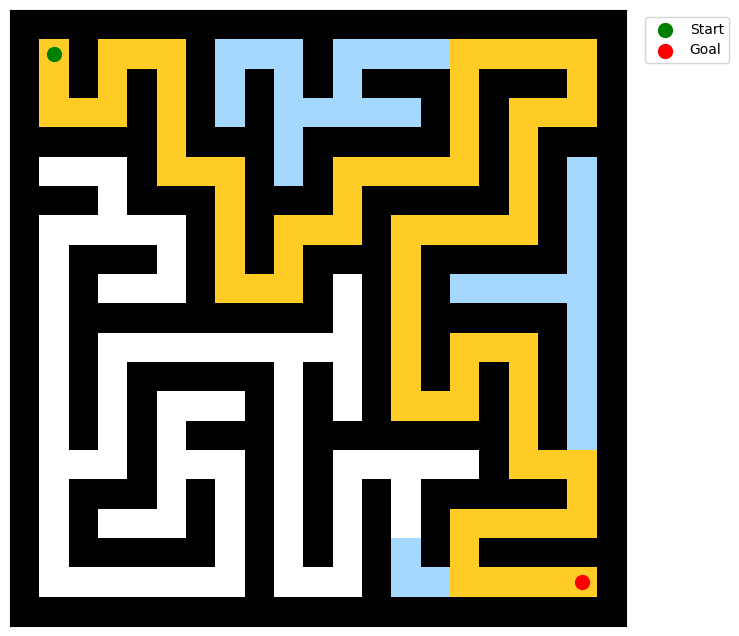

ゴールに到達しました
最短移動回数: 80
発見したマス数: 117


In [24]:
path, visited = solve_maze_bfs(
    maze,
    start,
    goal,
    delay=0.1,
    animate=True,
)

if path is None:
    print("ゴールまでの経路が見つかりませんでした")
else:
    print("ゴールに到達しました")
    print(f"最短移動回数: {len(path) - 1}")
    print(f"発見したマス数: {len(visited)}")